
# ASSIGNMENT 8 — Building a Variational Autoencoder and Visualising Its Latent Space

## Objective
The objective of this assignment is to understand how a **Variational Autoencoder (VAE)** learns a structured latent space.

### Tasks
- Build a VAE using the **MNIST** handwritten digit dataset.
- Use a **2-dimensional latent space**.
- Train the VAE for approximately **20 epochs**.
- Record **Reconstruction Loss** and **KL-Divergence Loss** separately.
- Encode test images and visualise their 2D latent representations.
- Colour latent points according to digit labels from **0 to 9**.
- Sample points across the latent space from approximately **-3 to +3** and decode them into digit images.
- Write short observations about clustering and smooth transitions.

> **Note:** This notebook is designed to run in Google Colab or a local Jupyter Notebook with TensorFlow installed.


## 1. Import Libraries

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 2. Load and Preprocess the MNIST Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28, 1)
Test images: (10000, 28, 28, 1)


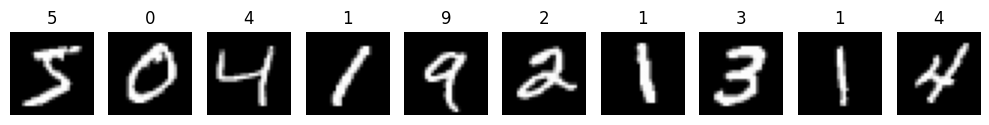

In [3]:

# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Convert pixels from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

# Display a few examples
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()



## 3. Build the Encoder

The encoder converts each 28×28 MNIST image into two vectors:

- **z_mean** — the mean of the latent Gaussian distribution
- **z_log_var** — the logarithm of its variance

The latent space has only **2 dimensions**, which allows us to plot it directly.


In [4]:

latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var],
    name="encoder"
)

encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


## 4. Reparameterization Trick

A VAE samples from a distribution instead of directly producing one fixed latent vector.

The reparameterization trick is:

**z = mean + exp(0.5 × log_variance) × random_noise**


In [5]:

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


z = Sampling()([z_mean, z_log_var])

encoder_with_sampling = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder_with_sampling"
)


## 5. Build the Decoder

In [6]:

latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")

x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

decoder_outputs = layers.Conv2D(
    1, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)


## 6. Create the Variational Autoencoder

The VAE uses two main loss components:

### Reconstruction Loss
Measures how closely the reconstructed image matches the original MNIST image.

### KL-Divergence Loss
Encourages the learned latent distribution to remain close to a standard normal distribution.

The total loss is:

**Total Loss = Reconstruction Loss + KL-Divergence Loss**


In [7]:

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            # Binary cross-entropy per pixel, summed over image dimensions
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            # KL divergence between learned Gaussian and N(0, I)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)


vae = VAE(encoder_with_sampling, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

print("VAE created successfully.")


VAE created successfully.


## 7. Train the VAE for 20 Epochs

In [9]:
# Train the VAE for 20 epochs

batch_size = 128
epochs = 20

history = vae.fit(
    x_train,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 5.0311 - loss: 164.8688 - reconstruction_loss: 159.8377
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.5772 - loss: 157.4571 - reconstruction_loss: 151.8798
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.7666 - loss: 154.7825 - reconstruction_loss: 149.0159
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.9155 - loss: 153.0416 - reconstruction_loss: 147.1261
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.0113 - loss: 151.7768 - reconstruction_loss: 145.7655
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.0905 - loss: 150.7362 - reconstruction_loss: 144.6457
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.1607 - loss: 149.8888 - reconstruction_loss: 143.7281
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.2076 - loss: 149.0869 - reconstruction_loss: 142.8793
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/s

## 8. Plot Reconstruction and KL-Divergence Loss

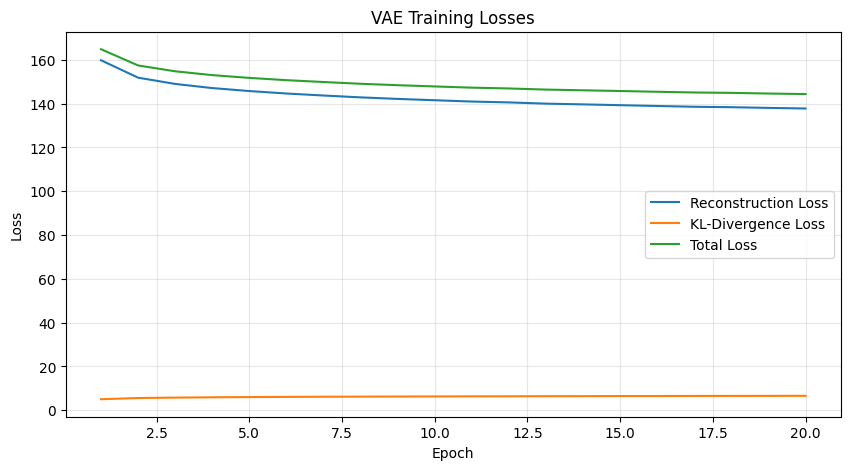

Final Reconstruction Loss: 137.7980499267578
Final KL-Divergence Loss: 6.5857744216918945
Final Total Loss: 144.38372802734375


In [10]:

# Extract recorded losses
total_loss = history.history["loss"]
reconstruction_loss = history.history["reconstruction_loss"]
kl_loss = history.history["kl_loss"]

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), reconstruction_loss, label="Reconstruction Loss")
plt.plot(range(1, epochs + 1), kl_loss, label="KL-Divergence Loss")
plt.plot(range(1, epochs + 1), total_loss, label="Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final Reconstruction Loss:", reconstruction_loss[-1])
print("Final KL-Divergence Loss:", kl_loss[-1])
print("Final Total Loss:", total_loss[-1])



## 9. Visualise the 2D Latent Space

The test images are passed through the encoder. Their latent means are plotted as points.

Each point is coloured according to its actual digit label from **0 to 9**.


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


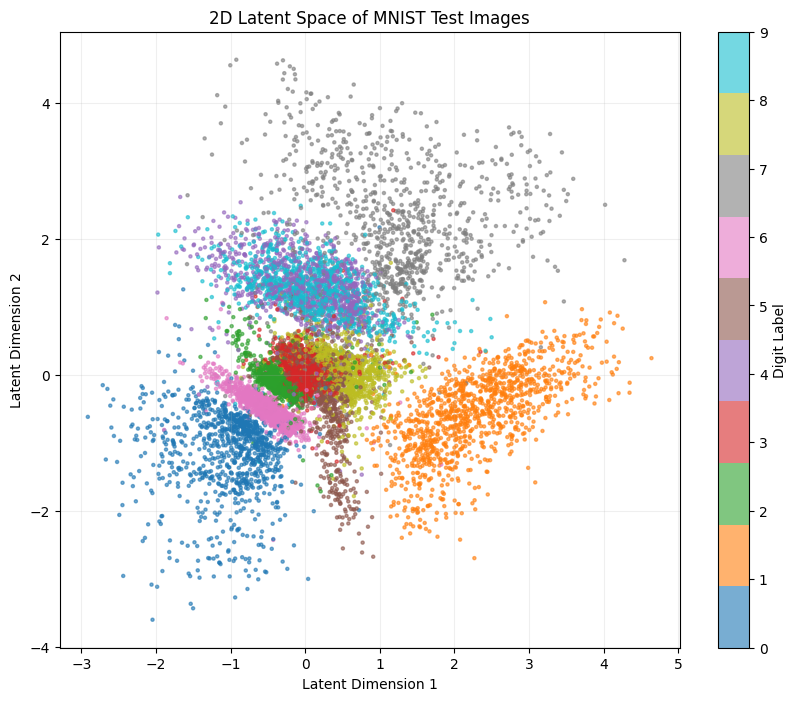

In [11]:

# Encode the test set
z_mean_test, z_log_var_test, z_test = encoder_with_sampling.predict(
    x_test, batch_size=256, verbose=1
)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.6
)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit Label")

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space of MNIST Test Images")
plt.grid(alpha=0.2)
plt.show()



## 10. Decode Points Across the Latent Space

The following grid selects points from approximately **-3 to +3** in both latent dimensions.

Each point is passed through the decoder to generate an MNIST-like digit image.

If the VAE has learned a smooth latent representation, neighbouring points should produce visually related digits and gradual changes rather than completely random jumps.


Decoded shape: (225, 28, 28)


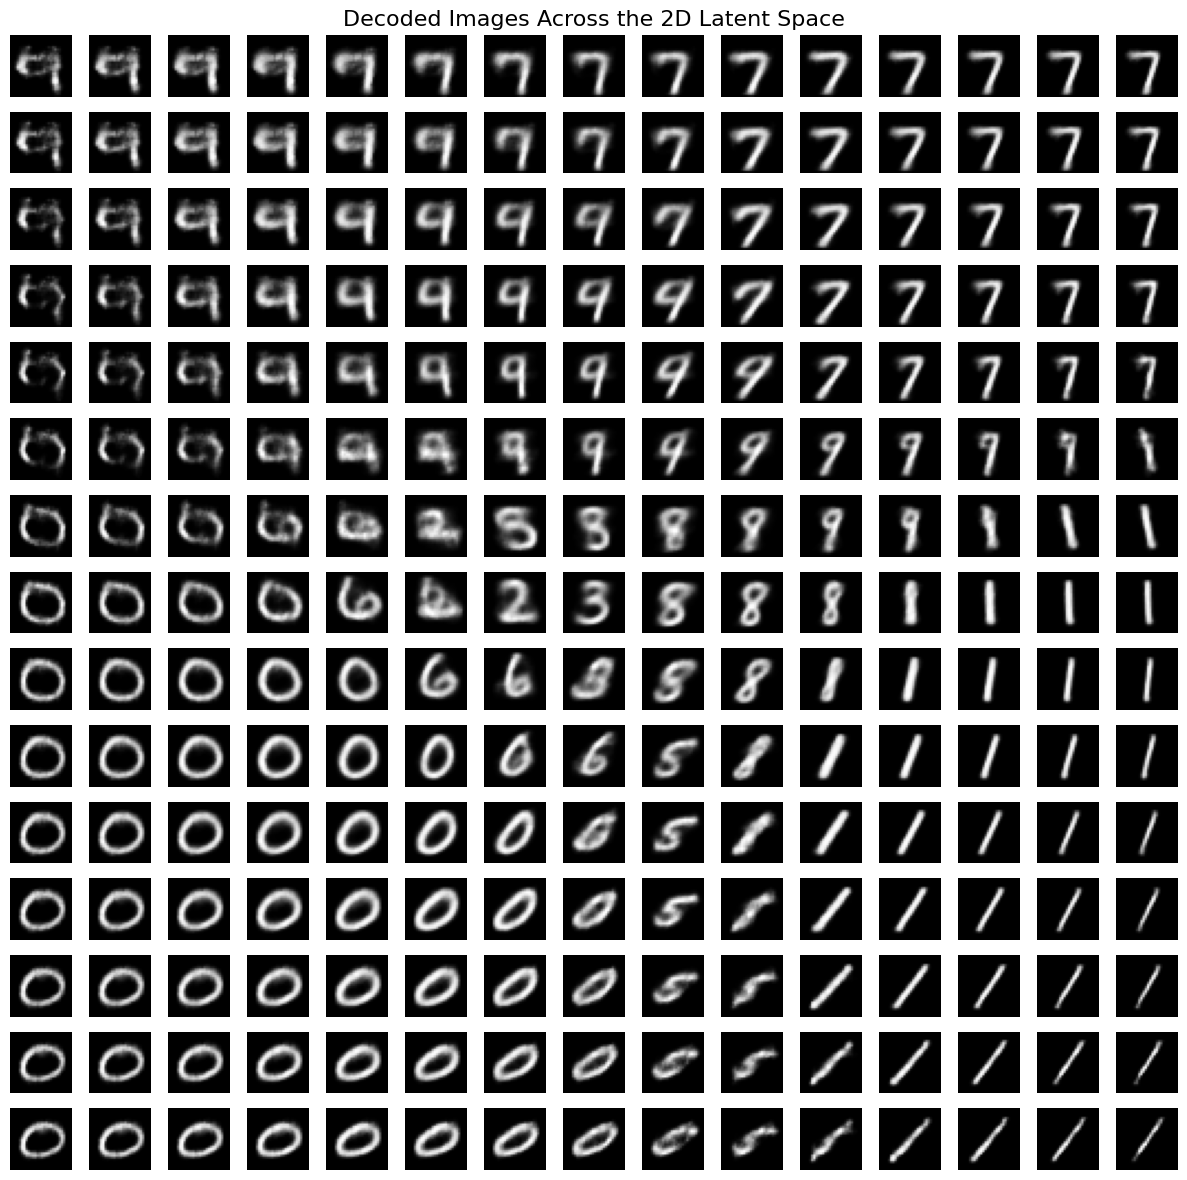

In [13]:
# Create a grid of latent points from -3 to +3
grid_size = 15

grid_x = np.linspace(-3, 3, grid_size)
grid_y = np.linspace(-3, 3, grid_size)[::-1]

mesh_x, mesh_y = np.meshgrid(grid_x, grid_y)

z_grid = np.stack(
    [mesh_x.ravel(), mesh_y.ravel()],
    axis=1
).astype("float32")

# Decode the latent points
decoded = decoder.predict(z_grid, verbose=0)

# Remove the final channel dimension
decoded = decoded.squeeze()

print("Decoded shape:", decoded.shape)

# Display decoded images
plt.figure(figsize=(12, 12))

for i in range(grid_size * grid_size):
    ax = plt.subplot(grid_size, grid_size, i + 1)
    ax.imshow(decoded[i], cmap="gray")
    ax.axis("off")

plt.suptitle(
    "Decoded Images Across the 2D Latent Space",
    fontsize=16
)

plt.tight_layout()
plt.show()


## 11. Compare Original and Reconstructed Images

This section gives a quick visual check of how well the VAE reconstructs real MNIST test images.


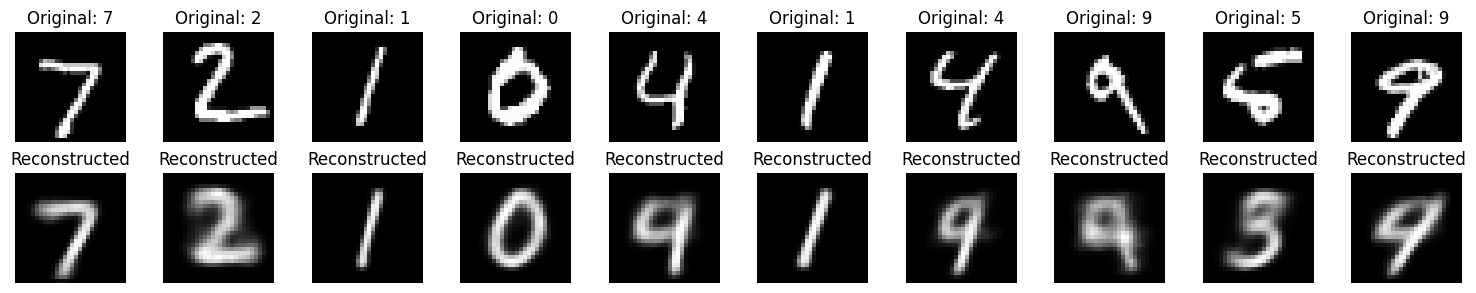

In [14]:

# Reconstruct a small sample
sample_images = x_test[:10]
sample_z_mean, sample_z_log_var, sample_z = encoder_with_sampling.predict(
    sample_images, verbose=0
)
reconstructed = decoder.predict(sample_z, verbose=0)

plt.figure(figsize=(15, 3))

for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(f"Original: {y_test[i]}")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 12. Observations

After running the notebook, complete or adjust the observations below based on the generated plots.

#### Latent-space clustering
Similar digits generally tend to form regions or clusters in the 2D latent space. For example, visually similar digits can appear relatively close together because the encoder learns features that help represent their shapes.

#### Cluster separation
The digit clusters are usually **partially separated rather than perfectly separated**. Some overlap is expected because several handwritten digits have similar shapes or styles.

#### Gradual changes through latent space
When moving gradually through the latent space, the generated digits generally change gradually as well. The decoder learns a continuous mapping from latent coordinates to image space.

#### Smooth transitions
The transition between neighbouring generated images should appear reasonably smooth. Instead of changing from one unrelated digit to another instantly, strokes and shapes tend to change progressively.

#### Overall conclusion
The experiment demonstrates that a VAE can compress MNIST images into a small 2D latent representation while retaining useful information for reconstruction. The KL-divergence term encourages the latent space to remain organised and approximately Gaussian, which makes it possible to sample new points and generate digit-like images.
